In [58]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import plotly.graph_objects as go
import statsmodels.api as sm
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from reservoir_computing.datasets import PredLoader

### Упражнение 1

- В примере MLP измените `window_size` ($P$) с 12 на 24.
- Прокомментируйте результаты и объясните, почему производительность улучшилась.

In [59]:
ts_full = PredLoader().get_data('ElecRome')

# Resample the time series to hourly frequency
ts_hourly = np.mean(ts_full.reshape(-1, 6), axis=1)

# Use only the first 3000 time steps
time_series = ts_hourly[0:3000, None]
time_steps = np.arange(0, len(time_series))

Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)


In [60]:
ts_hourly.shape

(22896,)

In [61]:
# Split the time series into training and test sets
train_size = int(0.9*len(time_series))
tr = time_series[:train_size]
te = time_series[train_size:]

In [62]:
def create_windows(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size:i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

In [69]:
# Define window size and forecast horizon
window_size = 12
forecast_horizon = 24

# Create input-output pairs
X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)

# We are only interested in the last time step of the horizon
y_train = y_train[:, -1]
y_test = y_test[:, -1]

In [70]:
X_tr = [np.concatenate(i) for i in X_train]
X_te = [np.concatenate(i) for i in X_test]

In [71]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)
X_test_scaled = scaler.transform(X_te)

In [72]:
# Define and train the neural network
mlp = MLPRegressor(hidden_layer_sizes=(16,8), activation='relu', solver='adam', max_iter=1000)
mlp.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,loss,'squared_error'
,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


In [74]:
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


window_size = 12

In [75]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 26.54


window_size = 24

In [68]:

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


Mean Squared Error: 38.58


24-часовое окно лучше сглаживает случайные шумы внутри дня, позволяя MLP уловить общий уровень потребления, который за 12 часов может сильно исказиться.

### Упражнение 2
— В MLP измените «forecast_horizon» с 24 на 36.
- Сделайте то же самое и в ESN.
- С горизонтом прогноза размером 24 мы использовали в качестве бейзлайна MSE между временным рядом и его версией, смещенной на 24 лага, `mse =mean_squared_error(y_test[24:], y_test[:-24])`. Является ли это хорошей базой даже при изменении горизонта прогнозирования? Что может быть лучшим базлайном?

In [81]:
# Define window size and forecast horizon
window_size = 12
forecast_horizon = 36

# Create input-output pairs
X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)

# We are only interested in the last time step of the horizon
y_train = y_train[:, -1]
y_test = y_test[:, -1]

In [82]:
X_train.shape

(2653, 12, 1)

In [83]:
X_tr = [np.concatenate(i) for i in X_train]
X_te = [np.concatenate(i) for i in X_test]

In [84]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)
X_test_scaled = scaler.transform(X_te)

In [85]:
# Define and train the neural network
mlp = MLPRegressor(hidden_layer_sizes=(16,8), activation='relu', solver='adam', max_iter=1000)
mlp.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,loss,'squared_error'
,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


In [86]:
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


Mean Squared Error: 39.67


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


ESN

In [87]:
# Generate training and test datasets
Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(time_series,
                                                      horizon=36, # forecast horizon of 24h ahead
                                                      test_percent = 0.1)
print(f"Xtr shape: {Xtr.shape}\nYtr shape: {Ytr.shape}\nXte shape: {Xte.shape}\nYte shape: {Yte.shape}")

Xtr shape: (2664, 2)
Ytr shape: (2664, 1)
Xte shape: (264, 2)
Yte shape: (264, 1)


In [88]:
res= Reservoir(n_internal_units=900,
               spectral_radius=0.99,
               input_scaling=0.1,
               connectivity=0.25)

In [89]:
n_drop=10
states_tr = res.get_states(Xtr[None,:,:], n_drop=n_drop, bidir=False)
states_te = res.get_states(Xte[None,:,:], n_drop=n_drop, bidir=False)
print(f"states_tr shape: {states_tr.shape}\nstates_te shape: {states_te.shape}")

states_tr shape: (1, 2654, 900)
states_te shape: (1, 254, 900)


In [90]:
# Fit the ridge regression model
ridge = Ridge(alpha=1.0)
time_start = time.time()
ridge.fit(states_tr[0], Ytr[n_drop:,:])
print(f"Training time: {time.time()-time_start:.4f}s")

# Compute the predictions
time_start = time.time()
Yhat = ridge.predict(states_te[0])
print(f"Test time: {time.time()-time_start:.4f}s")

Training time: 0.0314s
Test time: 0.0011s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/pytho

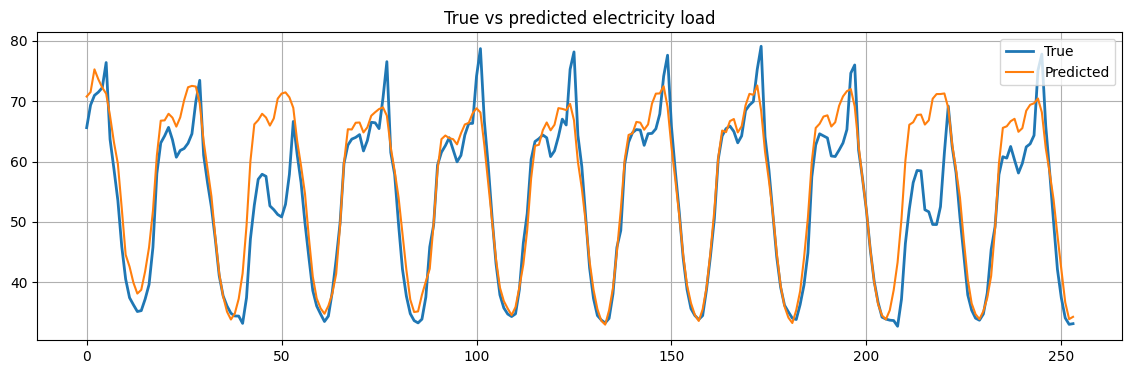

In [91]:
fig = plt.figure(figsize=(14,4))
plt.plot(Yte[n_drop:,:], label="True", linewidth=2)
plt.plot(scaler.inverse_transform(Yhat.reshape(-1, 1)), label="Predicted")
plt.grid()
plt.legend()
plt.title("True vs predicted electricity load")
plt.show()

In [92]:
mse = mean_squared_error(scaler.inverse_transform(Yhat.reshape(-1, 1)), Yte[n_drop:,:])
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 31.96


In [93]:
mse = mean_squared_error(Yte[24:], Yte[:-24])
mse

27.247166240637238

При изменении горизонта прогнозирования наш beselien становится плохим. так как он игнорирует инерцию процесса на коротких дистанциях и не учитывает недельную цикличность на длинных.

Хорошим альтернативным beseline может выступить сезонное среднее (среднее за такие же предыдущие периоды, например среднее потребление по понедельникам)

### Упражнение 3

В отличие от подхода, основанного на моделях, такого как ARIMA, MLP и ESN строго не требуют, чтобы данные были стационарными. Однако, устранив тренд и сезонность, MLP и ESN могут сосредоточиться только на прогнозировании остатков.

- Удалите тренд и сезонность и обучите MLP и ESN обучению остатков.
- При тестировании не забывайте учитывать тенденцию и сезонность при расчете прогнозов.
- Сравните результаты с результатами, полученными при обучении MLP и ESN на исходных данных.

In [94]:
from statsmodels.tsa.seasonal import seasonal_decompose
window_size = 12
forecast_horizon = 24
period = 5

decomposition = seasonal_decompose(time_series, model='additive', period=period)

# Извлекаем компоненты
# Извлекаем компоненты
trend = decomposition.trend
seasonal = decomposition.seasonal
residuals = decomposition.resid

# Убираем NaN, которые образуются при декомпозиции
# Важно сохранить индексы для последующего восстановления тренда/сезонности
valid_idx = ~np.isnan(residuals)
res_clean = residuals[valid_idx]
trend_clean = trend[valid_idx]
seasonal_clean = seasonal[valid_idx]
original_clean = time_series[valid_idx]

In [ ]:
res_clean.shape

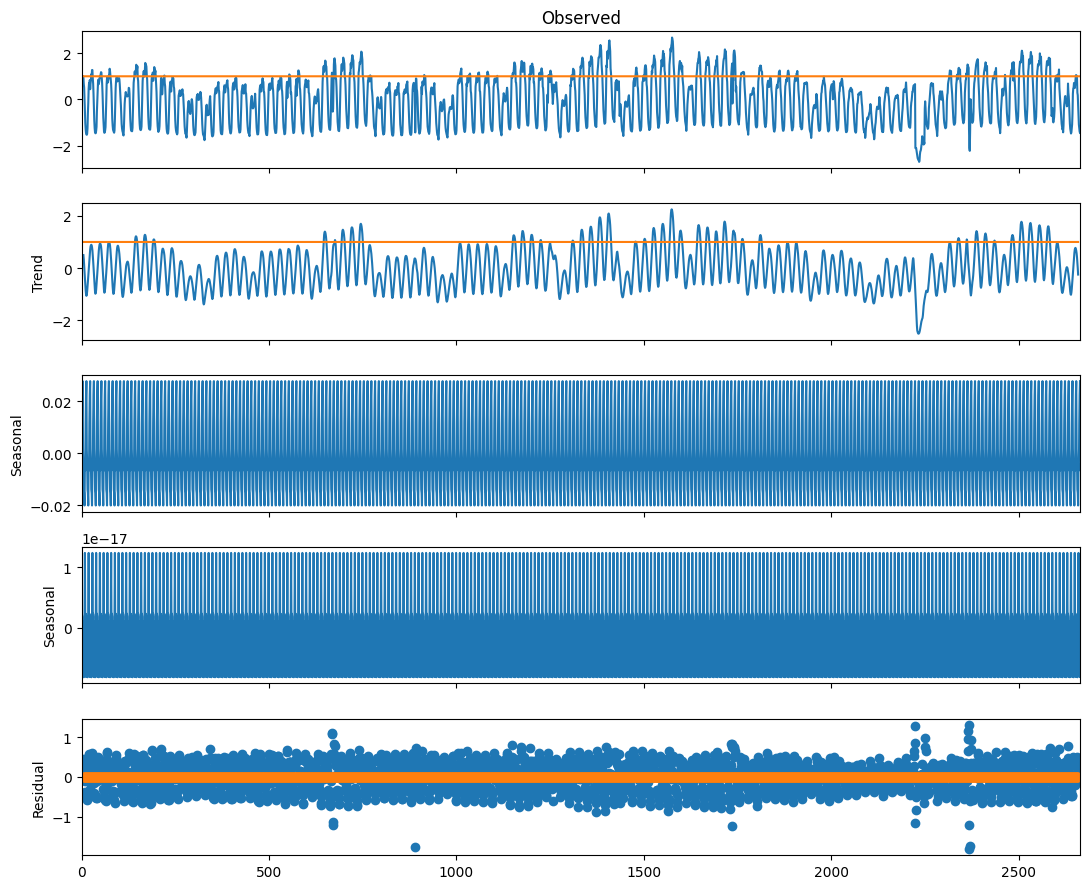

In [95]:
# импортируем функцию seasonal_decompose из statsmodels
# (то есть осуществляем декомпозицию сигнала/временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


# применяем функцию к данным о перевозках
decompose = seasonal_decompose(Xtr, period=10)
decompose.plot()
plt.show()

Удалим тренд и сезонность

In [ ]:
tr.shape

In [96]:
train_size = int(0.9*len(res_clean))
tr = res_clean[:train_size]
te = res_clean[train_size:]

In [97]:
# Define window size and forecast horizon
window_size = 12
forecast_horizon = 36

# Create input-output pairs
X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)

# We are only interested in the last time step of the horizon
y_train = y_train[:, -1]
y_test = y_test[:, -1]

In [98]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
# Define and train the neural network
mlp = MLPRegressor(hidden_layer_sizes=(16,8), activation='relu', solver='adam', max_iter=1000)
mlp.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,loss,'squared_error'
,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


In [100]:
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


Mean Squared Error: 6.61


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


ESN

In [101]:
# Generate training and test datasets
Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(res_clean.reshape(-1, 1),
                                                      horizon=36, # forecast horizon of 24h ahead
                                                      test_percent = 0.1)
print(f"Xtr shape: {Xtr.shape}\nYtr shape: {Ytr.shape}\nXte shape: {Xte.shape}\nYte shape: {Yte.shape}")

Xtr shape: (2660, 2)
Ytr shape: (2660, 1)
Xte shape: (264, 2)
Yte shape: (264, 1)


In [102]:
res= Reservoir(n_internal_units=900,
               spectral_radius=0.99,
               input_scaling=0.1,
               connectivity=0.25)

In [103]:
n_drop=10
states_tr = res.get_states(Xtr[None,:,:], n_drop=n_drop, bidir=False)
states_te = res.get_states(Xte[None,:,:], n_drop=n_drop, bidir=False)
print(f"states_tr shape: {states_tr.shape}\nstates_te shape: {states_te.shape}")

states_tr shape: (1, 2650, 900)
states_te shape: (1, 254, 900)


In [104]:
# Fit the ridge regression model
ridge = Ridge(alpha=1.0)
time_start = time.time()
ridge.fit(states_tr[0], Ytr[n_drop:,:])
print(f"Training time: {time.time()-time_start:.4f}s")

# Compute the predictions
time_start = time.time()
Yhat = ridge.predict(states_te[0])
print(f"Test time: {time.time()-time_start:.4f}s")

Training time: 0.0316s
Test time: 0.0005s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/pytho

In [105]:
mse = mean_squared_error(scaler.inverse_transform(Yhat.reshape(-1, 1)), Yte[n_drop:,:])
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 3.36


Обучение на стационарных остатках радикально повысило точность, снизив ошибку MSE примерно в 6-10 раз по сравнению с обучением на исходных данных.

### Упражнение 4

В этом упражнении мы рассмотрим новый набор данных, состоящий из почасовых значений температуры воды в Мексиканском заливе недалеко от Ки-Уэста, Флорида.
Почасовые температуры указаны с 3 октября 2016 г. по 3 октября 2017 г.
Набор данных состоит из кадра данных с 6572 наблюдениями по следующим трем переменным.

- `DateTime` Дата и время чтения (формат мм/дд/гггг ч:м).
- «WaterTemp»: температура воды (в градусах Фаренгейта).
- `t`: индекс времени (от 1 до 673).

Raw data:
------------------
          DateTime  WaterTemp  t
0  10/3/2016 0:00       86.2  1
1  10/3/2016 1:00       86.2  2
2  10/3/2016 2:00       86.2  3
3  10/3/2016 3:00       86.2  4
4  10/3/2016 4:00       86.0  5


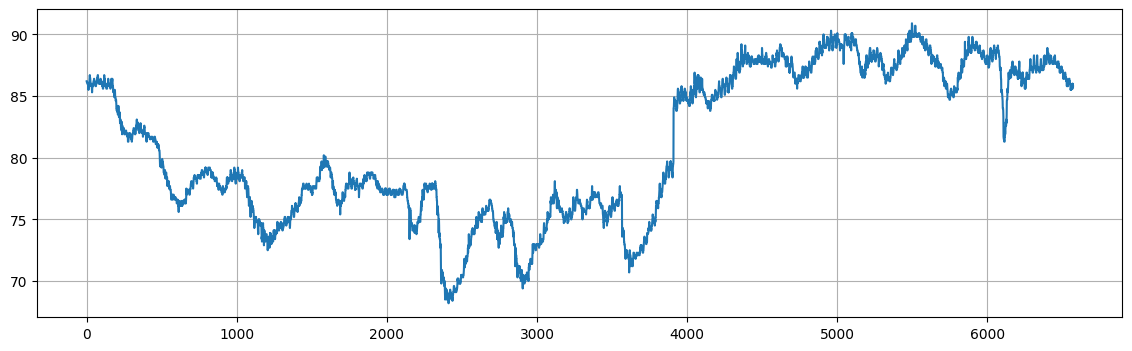

In [106]:

temps = sm.datasets.get_rdataset("KeyWestWater", "Stat2Data").data
print("Raw data:\n------------------\n", temps.head())
plt.figure(figsize=(14,4))
plt.plot(temps["WaterTemp"])
plt.grid()
plt.show()

- Примените MLP к данным температуры. 
- Выполните поиск по небольшой сетке, чтобы попробовать разные значения для следующих гиперпараметров: 
- `hidden_layer_sizes` (например, попробуйте больше слоев `[16, 16, 8]`, слоев с большим количеством блоков `[32, 16]` и т. д.). 
- `learning_rate_init`. 
- «активация» (попробуйте хотя бы «tanh» и «relu»). 
- Примените ESN к данным температуры. 
- Выполните поиск по небольшой сетке, чтобы попробовать разные значения для следующих гиперпараметров: 
- `спектральный_радиус`. 
- `input_scaling`. 
- `n_internal_units`. 
- `связность`. 

Сообщите о конфигурации MLP и ESN, которая обеспечивает наилучшую производительность на тестовых данных.

In [107]:
# Prepare the temperature series
time_series = temps["WaterTemp"].values.reshape(-1, 1)

train_size = int(0.9 * len(time_series))
tr = time_series[:train_size]
te = time_series[train_size:]

# Define window size and forecast horizon
window_size = 12
forecast_horizon = 36

# Create input-output pairs
X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)

# We are only interested in the last time step of the horizon
y_train = y_train[:, -1]
y_test = y_test[:, -1]



In [108]:
X_train.shape

(5867, 12, 1)

In [109]:
X_tr = [np.concatenate(i) for i in X_train]
X_te = [np.concatenate(i) for i in X_test]

In [110]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)
X_test_scaled = scaler.transform(X_te)

In [111]:
from sklearn.model_selection import GridSearchCV

# define parameter grid for MLP
param_grid = {
    'hidden_layer_sizes': [(16,16,8), (32,16), (64,32), (32,32,16)],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'activation': ['relu', 'tanh']
}

mlp = MLPRegressor(solver='adam', max_iter=1000)
grid_mlp = GridSearchCV(mlp, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_mlp.fit(X_train_scaled, y_train)


best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scaled)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWar

In [112]:
print("Best MLP params:", grid_mlp.best_params_)
print(f"Test MLP MSE: {mse_mlp:.2f}")

Best MLP params: {'activation': 'relu', 'hidden_layer_sizes': (16, 16, 8), 'learning_rate_init': 0.1}
Test MLP MSE: 7.44


In [113]:
# ESN grid search
best_mse_esn = np.inf
best_params_esn = None

for radius in [0.8, 0.9, 0.99]:
    for scaling in [0.1, 0.5, 1.0]:
        for units in [100, 300, 500]:
            for conn in [0.1, 0.25, 0.5]:
                res = Reservoir(n_internal_units=units,
                                spectral_radius=radius,
                                input_scaling=scaling,
                                connectivity=conn)
                n_drop = 10
                states_tr = res.get_states(X_train_scaled[None, :, :], n_drop=n_drop, bidir=False)
                states_te = res.get_states(X_test_scaled[None, :, :], n_drop=n_drop, bidir=False)
                ridge = Ridge(alpha=1.0)
                ridge.fit(states_tr[0], y_train[n_drop:])
                yhat = ridge.predict(states_te[0])
                mse_val = mean_squared_error(y_test[n_drop:], yhat)
                if mse_val < best_mse_esn:
                    best_mse_esn = mse_val
                    best_params_esn = (radius, scaling, units, conn)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

In [114]:
print("Best ESN params (radius, scaling, units, conn):", best_params_esn)
print("Best ESN test MSE:", best_mse_esn)

Best ESN params (radius, scaling, units, conn): (0.99, 1.0, 100, 0.1)
Best ESN test MSE: 2.6630498129647684
